# LR × Concentration Sweep

2D grid sweep over learning rate and burst fraction.  
Pretrain once, then run all (lr, frac) combos in parallel.  
Heatmaps show how the two knobs interact across key metrics.

In [1]:
import sys, os, importlib
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")

import simple.model, simple.data, simple.pretrain, simple.finetune, simple.forget, simple.interp, simple.report
for name in ["simple.model", "simple.data", "simple.pretrain", "simple.finetune",
             "simple.forget", "simple.interp", "simple.report"]:
    importlib.reload(sys.modules[name])

from simple import make_data, pretrain, finetune, forget, report
from simple.finetune import _finetune_worker
from simple.forget import _forget_worker
import torch.multiprocessing as mp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

OUT = "data/lr_sweep"
SEED = 42

## Sweep Configuration

In [ ]:
# ── Sweep grid ──────────────────────────────────────────
LRS =  [5e-5, 1e-4, 3e-4, 1e-3]
FRACS = [1.0, 0.9, 0.7, 0.5, 0.3]

FT_STEPS = 1500
FG_STEPS = 600

print(f"Grid: {len(LRS)} LRs × {len(FRACS)} fracs = {len(LRS)*len(FRACS)} runs")

Grid: 5 LRs × 5 fracs = 25 runs


## 1. Data & Pretrain (once)

Other tasks: 64, Burst tasks: 64


Pretrain: 0it [00:00, ?it/s]


Converged at step 600 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=0.9992, final loss_other=0.5894


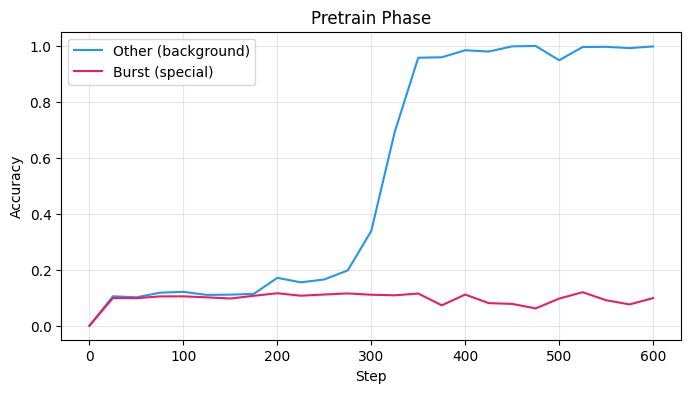

Checkpoint: data/lr_sweep/pretrain/pretrain_ckpt.pt


In [3]:
data = make_data(depth=3, burst_pos=3, n_a=4, n_burst=4, seed=SEED)
print(f"Other tasks: {data['task_info']['n_other_tasks']}, Burst tasks: {data['task_info']['n_burst_tasks']}")

pt = pretrain(data, f"{OUT}/pretrain", seed=SEED)
report.plot_pretrain(pt)
plt.show()
print(f"Checkpoint: {pt['ckpt_path']}")

## 2. Finetune + Forget sweep

In [4]:
# Run all finetune + forget jobs sequentially (better GPU utilization)
from simple.finetune import finetune as _finetune_fn
from simple.forget import forget as _forget_fn

ft_results = []
for lr in LRS:
    for frac in FRACS:
        tag = f"lr{lr:.0e}_burst_{int(frac*100)}"
        print(f"  FT {tag}...", end=" ", flush=True)
        r = _finetune_fn(data=data, pretrain_ckpt=pt["ckpt_path"],
                         out_dir=f"{OUT}/finetune",
                         burst_frac=frac, steps=FT_STEPS, lr=lr,
                         tag=tag, seed=SEED, quiet=True)
        ft_results.append(r)
        print(f"peak={r['peak_burst']:.3f}")

FG_LR = 1e-4
fg_results = []
for ft_r in ft_results:
    print(f"  FG {ft_r['tag']}...", end=" ", flush=True)
    r = _forget_fn(data=data, finetune_ckpt=ft_r["ckpt_path"],
                   pretrain_ckpt=pt["ckpt_path"],
                   out_dir=f"{OUT}/forget",
                   steps=FG_STEPS, lr=FG_LR,
                   tag=ft_r["tag"], seed=SEED, quiet=True)
    fg_results.append(r)
    print(f"drop={r['dropoff_pct']:.1f}%")

print("Done!")

# Save results to disk
import pickle
results_path = f"{OUT}/sweep_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump({"ft_results": ft_results, "fg_results": fg_results,
                 "LRS": LRS, "FRACS": FRACS, "FT_STEPS": FT_STEPS,
                 "FG_STEPS": FG_STEPS, "FG_LR": FG_LR}, f)
print(f"Results saved to {results_path}")

  FT lr1e-05_burst_100... peak=0.657
  FT lr1e-05_burst_90... peak=0.763
  FT lr1e-05_burst_70... peak=0.649
  FT lr1e-05_burst_50... peak=0.576
  FT lr1e-05_burst_30... peak=0.501
  FT lr5e-05_burst_100... peak=1.000
  FT lr5e-05_burst_90... peak=1.000
  FT lr5e-05_burst_70... peak=1.000
  FT lr5e-05_burst_50... peak=1.000
  FT lr5e-05_burst_30... 

KeyboardInterrupt: 

## 3. Extract metrics into grids

In [ ]:
# ── Load saved results (skip training cells above) ──
# import pickle
# with open(f"{OUT}/sweep_results.pkl", "rb") as f:
#     saved = pickle.load(f)
# ft_results = saved["ft_results"]; fg_results = saved["fg_results"]
# LRS = saved["LRS"]; FRACS = saved["FRACS"]
# print(f"Loaded {len(ft_results)} FT + {len(fg_results)} FG results")

In [ ]:
n_lr, n_frac = len(LRS), len(FRACS)

# Initialize metric grids
grid_reversion_auc    = np.zeros((n_lr, n_frac))
grid_drop_pct         = np.zeros((n_lr, n_frac))
grid_peak_burst       = np.zeros((n_lr, n_frac))
# End of FT
grid_ft_end_bg_loss   = np.zeros((n_lr, n_frac))
grid_ft_end_bg_acc    = np.zeros((n_lr, n_frac))
grid_ft_end_burst_loss= np.zeros((n_lr, n_frac))
grid_ft_end_burst_acc = np.zeros((n_lr, n_frac))
# End of Forget
grid_fg_end_bg_loss   = np.zeros((n_lr, n_frac))
grid_fg_end_bg_acc    = np.zeros((n_lr, n_frac))
grid_fg_end_burst_loss= np.zeros((n_lr, n_frac))
grid_fg_end_burst_acc = np.zeros((n_lr, n_frac))
# Gradient metrics (FT)
grid_mean_cosine      = np.zeros((n_lr, n_frac))
grid_end_cosine       = np.zeros((n_lr, n_frac))
grid_mean_cos_bg      = np.zeros((n_lr, n_frac))
grid_mean_cos_burst   = np.zeros((n_lr, n_frac))
grid_mean_gnorm_bg    = np.zeros((n_lr, n_frac))
grid_mean_gnorm_burst = np.zeros((n_lr, n_frac))
grid_weight_drift     = np.zeros((n_lr, n_frac))

for idx, (ft_r, fg_r) in enumerate(zip(ft_results, fg_results)):
    i_lr = idx // n_frac
    i_fr = idx % n_frac
    ft_log = ft_r["log"]
    fg_log = fg_r["log"]

    grid_reversion_auc[i_lr, i_fr]  = fg_r["reversion_auc"]
    grid_drop_pct[i_lr, i_fr]       = fg_r["dropoff_pct"]
    grid_peak_burst[i_lr, i_fr]     = ft_r["peak_burst"]

    # End of FT
    grid_ft_end_bg_loss[i_lr, i_fr]    = ft_log["loss_other"][-1]
    grid_ft_end_bg_acc[i_lr, i_fr]     = ft_log["acc_other"][-1]
    grid_ft_end_burst_loss[i_lr, i_fr] = ft_log["loss_burst"][-1]
    grid_ft_end_burst_acc[i_lr, i_fr]  = ft_log["acc_burst"][-1]

    # End of Forget
    grid_fg_end_bg_loss[i_lr, i_fr]    = fg_log["loss_other"][-1]
    grid_fg_end_bg_acc[i_lr, i_fr]     = fg_log["acc_other"][-1]
    grid_fg_end_burst_loss[i_lr, i_fr] = fg_log["loss_burst"][-1]
    grid_fg_end_burst_acc[i_lr, i_fr]  = fg_log["acc_burst"][-1]

    # Gradient metrics
    cos = ft_log.get("grad_cosine_burst_bg", [])
    grid_mean_cosine[i_lr, i_fr]  = np.mean(cos) if cos else 0
    grid_end_cosine[i_lr, i_fr]   = cos[-1] if cos else 0

    gn_bg = ft_log.get("grad_norm_bg", [])
    gn_burst = ft_log.get("grad_norm_burst", [])
    grid_mean_gnorm_bg[i_lr, i_fr]    = np.mean(gn_bg) if gn_bg else 0
    grid_mean_gnorm_burst[i_lr, i_fr] = np.mean(gn_burst) if gn_burst else 0

    if cos and gn_bg:
        grid_mean_cos_bg[i_lr, i_fr] = np.mean([c*n for c, n in zip(cos, gn_bg)])
    if cos and gn_burst:
        grid_mean_cos_burst[i_lr, i_fr] = np.mean([c*n for c, n in zip(cos, gn_burst)])

    wd = ft_log.get("weight_drift", [])
    grid_weight_drift[i_lr, i_fr] = wd[-1] if wd else 0

print("Metrics extracted.")

## 4. Heatmaps

In [ ]:
lr_labels = [f"{lr:.0e}" for lr in LRS]
frac_labels = [f"{int(f*100)}%" for f in FRACS]

grids = [
    # ── Summary ──
    ("Reversion AUC (higher = more retained)", grid_reversion_auc, "RdYlGn"),
    ("Accuracy Drop %", grid_drop_pct, "RdYlGn_r"),
    ("Peak Burst Accuracy (FT)", grid_peak_burst, "YlGn"),
    # ── End of FT ──
    ("BG Accuracy (end of FT)", grid_ft_end_bg_acc, "RdYlGn"),
    ("BG Loss (end of FT)", grid_ft_end_bg_loss, "YlOrRd"),
    ("Burst Accuracy (end of FT)", grid_ft_end_burst_acc, "YlGn"),
    ("Burst Loss (end of FT)", grid_ft_end_burst_loss, "YlOrRd"),
    # ── End of Forget ──
    ("BG Accuracy (end of Forget)", grid_fg_end_bg_acc, "RdYlGn"),
    ("BG Loss (end of Forget)", grid_fg_end_bg_loss, "YlOrRd"),
    ("Burst Accuracy (end of Forget)", grid_fg_end_burst_acc, "YlGn"),
    ("Burst Loss (end of Forget)", grid_fg_end_burst_loss, "YlOrRd"),
    # ── Gradient metrics (FT) ──
    ("Mean Gradient Cosine (burst vs bg)", grid_mean_cosine, "RdBu_r"),
    ("End Gradient Cosine (burst vs bg)", grid_end_cosine, "RdBu_r"),
    ("Mean Cosine × BG Grad Norm", grid_mean_cos_bg, "RdBu_r"),
    ("Mean Cosine × Burst Grad Norm", grid_mean_cos_burst, "RdBu_r"),
    ("Mean BG Grad Norm", grid_mean_gnorm_bg, "YlOrRd"),
    ("Mean Burst Grad Norm", grid_mean_gnorm_burst, "YlOrRd"),
    ("Weight Drift (end of FT)", grid_weight_drift, "YlOrRd"),
]

n_cols = 3
n_rows = (len(grids) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for idx, (title, grid, cmap) in enumerate(grids):
    ax = axes[idx]
    im = ax.imshow(grid, aspect="auto", cmap=cmap)
    ax.set_xticks(range(n_frac))
    ax.set_xticklabels(frac_labels, fontsize=9)
    ax.set_yticks(range(n_lr))
    ax.set_yticklabels(lr_labels, fontsize=9)
    ax.set_xlabel("Burst Fraction")
    ax.set_ylabel("Learning Rate")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Annotate cells
    for i in range(n_lr):
        for j in range(n_frac):
            val = grid[i, j]
            txt = f"{val:.2f}" if abs(val) < 100 else f"{val:.0f}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if abs(val - grid.min()) > 0.6 * (grid.max() - grid.min()) else "black")

# Hide unused axes
for idx in range(len(grids), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("LR × Burst Fraction Sweep", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Scatter: BG loss at end of FT vs Forgetting

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for idx, (ft_r, fg_r) in enumerate(zip(ft_results, fg_results)):
    i_lr = idx // n_frac
    frac = ft_r["burst_frac"]
    lr = LRS[i_lr]
    color = plt.cm.viridis(i_lr / max(n_lr - 1, 1))
    marker = "o" if frac >= 0.9 else ("s" if frac >= 0.5 else "^")

    bg_loss = ft_r["log"]["loss_other"][-1]
    drop = fg_r["dropoff_pct"]
    auc = fg_r["reversion_auc"]

    ax1.scatter(bg_loss, drop, c=[color], marker=marker, s=60, zorder=3)
    ax1.annotate(f"{int(frac*100)}%", (bg_loss, drop),
                 fontsize=6, textcoords="offset points", xytext=(3, 3))

    ax2.scatter(bg_loss, auc, c=[color], marker=marker, s=60, zorder=3)
    ax2.annotate(f"{int(frac*100)}%", (bg_loss, auc),
                 fontsize=6, textcoords="offset points", xytext=(3, 3))

# LR legend
for i, lr in enumerate(LRS):
    color = plt.cm.viridis(i / max(n_lr - 1, 1))
    ax1.scatter([], [], c=[color], label=f"lr={lr:.0e}", s=40)
    ax2.scatter([], [], c=[color], label=f"lr={lr:.0e}", s=40)

ax1.set_xlabel("BG Loss at End of FT"); ax1.set_ylabel("Drop %")
ax1.set_title("BG Loss → Forgetting Severity"); ax1.legend(fontsize=7); ax1.grid(True, alpha=0.3)
ax2.set_xlabel("BG Loss at End of FT"); ax2.set_ylabel("Reversion AUC")
ax2.set_title("BG Loss → Knowledge Retention"); ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()